# Manual Pipeline
- I made a mistake earlier. Should not have skipepd straight to building a pipeline.
- Verify the prior selection on a set of three stars first.
- Here we will do the first one.

---
- In this notebook:
    - Plot the stellar S-Ind data.
    - Run LSP on it.
    - Remove dominant mode.
    - Run LSP on residuals.
    - Flag aliases and window functions.
        - Aliases are harmonics of the dominant signal. For stars the dominant signal is probably $P_rot$
        - Window functions are regular due to observations ie daily, weekly, monthly etc.
    - Ignore these as bias.
    - Remaining peaks above FAP threshold are significant too.
    - Classify those significant peaks. (you alr have this from priors1)
    - Formulate priors.
    - GPR
    -Window analysis.
---
- Here will just do HD81809. 


In [51]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms
from scipy.optimize import minimize
from prettytable import PrettyTable


# Importing data
data = pd.read_csv(r"./Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)

# data = pd.read_csv(r"./Data/hd166_caii.txt", sep='\s',skip_blank_lines=True)
data.columns = ["JD", "sind"]
data['JD'] = data['JD'] + 2400000.0 # this file drops the 24 prefix
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data["day"] = time_obj.jd 
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')

# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.8, valid_split=0.19):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

# Split the data
train_df, valid_df, test_df = split_df(data)


C:\Users\Joey\AppData\Local\Temp\ipykernel_6812\3791637440.py:12: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)


- Nu skriver vi en MPFIT:
    - Find dominant peak:
        - Compare with SNR and FAP
        - Significant if peak_power > FAP threshold (and/or SNR > 4)
        - else stop
    - Add best_freq to accepted frequency list
    - Simultaneous re-fit of ALL accepted frequencies
    - Calculate new residuals
    - Repeat with new residuals.

[np.float64(1.0), np.float64(0.00033393517952323514), np.float64(3.339351795232352e-05), np.float64(0.18653333568698052)]


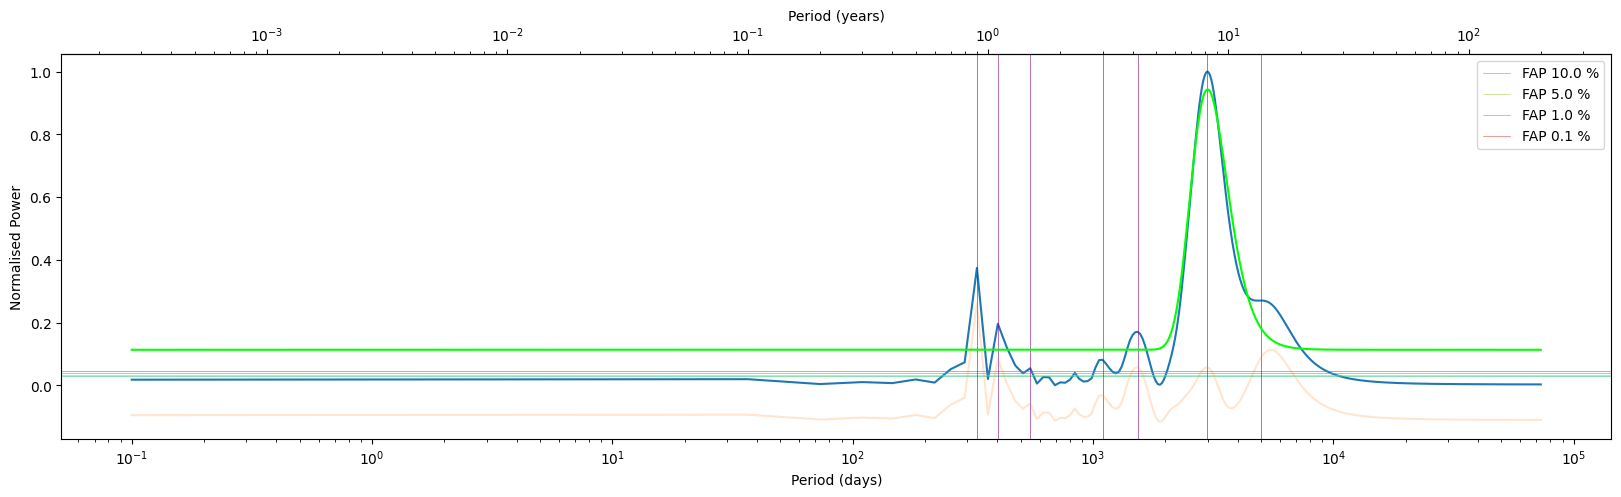

In [52]:
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# Define freq range
min_period = 0.1
max_period = 365*200 # now in days
n_periods = 2000
periods = np.linspace(min_period, max_period, n_periods)
freqs = 1 / periods

## Round 1
resid = train_df['sind']
t = train_df['day']

# Take the LSP
ls = LombScargle(t, resid)
powers = ls.power(freqs) # Pulls out the powers at those frequencies

# Normalisation for interpretability
max_power = max(powers)
powers /= max_power

# Calculate FAPs
FAPs = np.array([10,5,1,0.1])/100
power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
power_invFAPs /= max_power # Normalise onto our scale of 0 to 1

# Identify peaks above 0.1 FAP
peak_idxs, properties = find_peaks(powers, height = float(power_invFAPs[-1])) # peaks is an array of the indices of the input arrays with the peaks
peak_periods = periods[peak_idxs]

## Plot
fig, ax = plt.subplots(figsize=(20, 5))
ax.set_xscale('log')
# ax.set_yscale('log')
ax.plot(periods, powers)

# Axis labels
ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365.25, lambda y: y * 365.25))
ax2.set_xlabel('Period (years)')
ax.set_xlabel('Period (days)')
ax.set_ylabel('Normalised Power')

# Plot FAPs
fap_colors = ['#2ecc71', '#a8d44a', '#e67e22', '#e74c3c']
for power_invFAP, fap_color, fap_level in zip(power_invFAPs, fap_colors, FAPs):
    ax.axhline(power_invFAP, color = fap_color, label = f'FAP {fap_level * 100} %', lw = 0.4)

# Plot peaks
for peak_period in peak_periods:
    ax.axvline(peak_period, color = 'purple', lw = 0.4)


# Take the dominant period
peak_heights = properties['peak_heights']
dom_idx = np.argmax(peak_heights) # Index of dominant period in peaks list
dom_peak_idx = peak_idxs[dom_idx] # Concomitant idx in the powers 
dominant_period = peak_periods[dom_idx]

# Perform SNR check
def gaussian(t, A, mu, std, c):
    return A * np.exp(-0.5 * ((t - mu) / std)**2) + c

def find_snr(powers, freqs, dom_idx, dom_peak_idx, peak_periods, peak_heights, window = 150):
    n = len(powers)
    left  = max(0, dom_peak_idx - window)
    right = min(n, dom_peak_idx + window + 1)

    lim_powers = powers[left:right]
    lim_freqs = freqs[left:right]

    minf = min(lim_freqs)
    maxf = max(lim_freqs)

    A0 = peak_heights[dom_idx]
    mu0 = 1/peak_periods[dom_idx]
    # Use 10% of the centre frequency so std0 stays sensible even when the
    # window extends to the high-frequency edge (freqs[0]=10).
    std0 = mu0 * 0.1
    c0 = np.median(lim_powers)
    p0 = [A0, mu0, std0, c0]
    print(p0)

    try:
        popt, pcov = curve_fit(gaussian, lim_freqs, lim_powers,
                                            p0 = p0,
                                            bounds = ([0, minf, 0, 0], [np.inf, maxf, np.inf, np.inf]),
                                            )
        # LSP residual defined noise floor
        resid_lsp = lim_powers - gaussian(lim_freqs, *popt)
        noise_std = np.std(resid_lsp) # Noise fluctuation
        snr = A0 / noise_std
        return snr, popt, resid_lsp
    except (RuntimeError, ValueError):
        # RuntimeError: fit did not converge; ValueError: bounds/guess issue
        noise = np.mean(lim_powers)
        return powers[dom_idx] / noise, None, None

snr, popt, resid_lsp = find_snr(powers, freqs, dom_idx, dom_peak_idx, peak_periods, peak_heights)

if popt is not None:
    ax.plot(periods, gaussian(freqs, *popt), color = 'lime')
    ax.plot(periods, powers-gaussian(freqs, *popt), alpha = 0.2)

accepted_periods = []

if snr >4:
    accepted_periods.append(dominant_period)

plt.legend()
plt.show()

# Now do the simultneous fit based on all the accepted periods
def build_design_matrix(t, accepted_periods):
    cols = [np.ones(len(t))]
    for p in accepted_periods:
        cols.append(np.cos(2 * np.pi * t / p))
        cols.append(np.sin(2 * np.pi * t / p))
    return np.column_stack(cols)

def simultaneous_fit(t, y, accepted_freqs):
    X = build_design_matrix(t, accepted_freqs)
    params, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    fitted = X @ params
    residuals = y - fitted
    return residuals, params

resid1, params = simultaneous_fit(train_df['day'], train_df['sind'], accepted_periods)


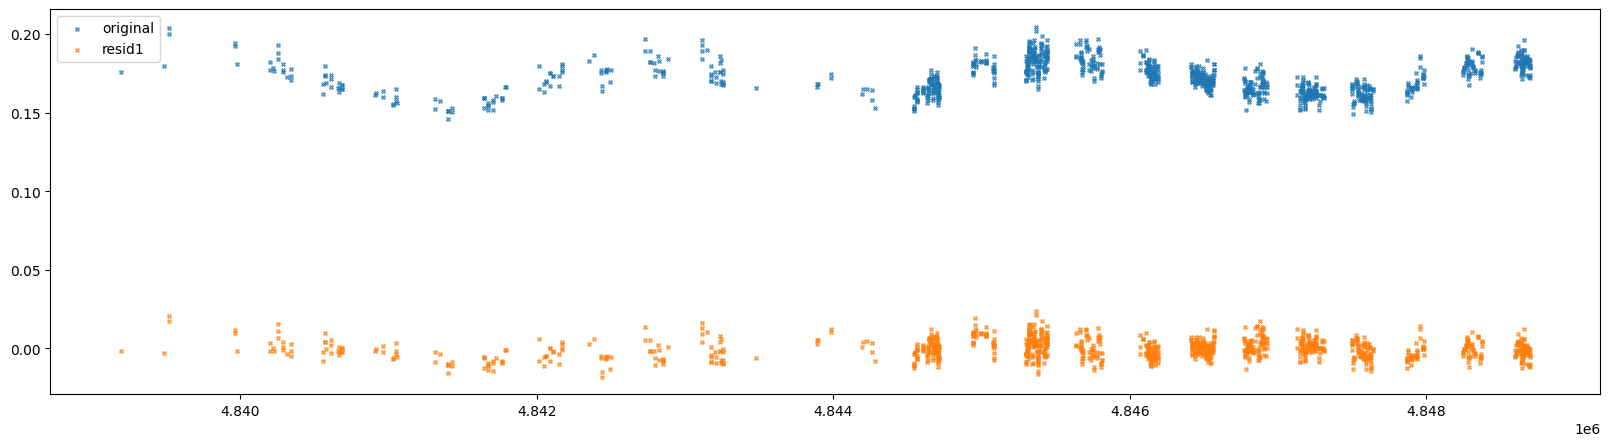

In [ ]:
fig = plt.figure(figsize=(20,5))
plt.scatter(train_df['day'], train_df['sind'], marker='x', s=7, alpha=0.75, label = 'original')
plt.scatter(train_df['day'], resid1, marker='x', s=7, alpha=0.75, label = "resid1")
plt.legend()
plt.show()

Accepted: [np.float64(2994.5931465732865)]
Windows: [365.25, 182.625, 121.75, 91.3125, 30.4375, 60.875, 7, 14, 21]
Aliases: [748.6482866433216, 988.2157383691846, 1497.2965732866433, 5989.186293146573, 8983.77943971986, 11978.372586293146]
+--------------------+--------------------+
|       Period       |       Height       |
+--------------------+--------------------+
| 7121.150775387694  |        1.0         |
| 1533.8647823911956 | 0.9092639409441785 |
| 2081.6379189594795 | 0.8624238592467487 |
+--------------------+--------------------+


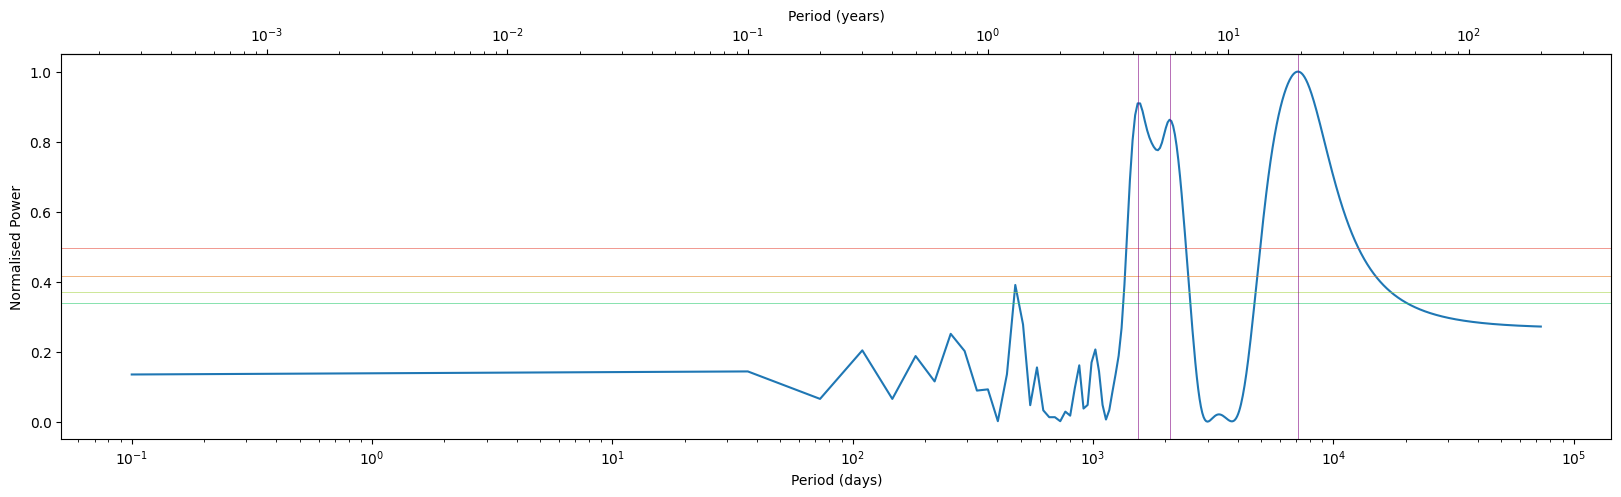

In [54]:
## ROUND 2

# Take the LSP
ls = LombScargle(t, resid1)
powers = ls.power(freqs) # Pulls out the powers at those frequencies

# Normalisation for interpretability
max_power = max(powers)
powers /= max_power

# Calculate FAPs
FAPs = np.array([10,5,1,0.1])/100
power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
power_invFAPs /= max_power # Normalise onto our scale of 0 to 1

# Identify peaks above 0.1 FAP
peak_idxs, properties = find_peaks(powers, height = float(power_invFAPs[-1])) # peaks is an array of the indices of the input arrays with the peaks
peak_periods = periods[peak_idxs]

## Plot
fig, ax = plt.subplots(figsize=(20, 5))
ax.set_xscale('log')
# ax.set_yscale('log')
ax.plot(periods, powers)

# Axis labels
ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365.25, lambda y: y * 365.25))
ax2.set_xlabel('Period (years)')
ax.set_xlabel('Period (days)')
ax.set_ylabel('Normalised Power')

# Plot FAPs
fap_colors = ['#2ecc71', '#a8d44a', '#e67e22', '#e74c3c']
for power_invFAP, fap_color, fap_level in zip(power_invFAPs, fap_colors, FAPs):
    ax.axhline(power_invFAP, color = fap_color, label = f'FAP {fap_level * 100} %', lw = 0.4)

# Plot peaks
for peak_period in peak_periods:
    ax.axvline(peak_period, color = 'purple', lw = 0.4)


# CHECK FOR ALIASES AND WINDOWS

# Loop through the peaks and find the first one that isn't an alias or window and perform the removal analysis
# peak_idxs, properties['peak_heights'], 

peak_heights = properties['peak_heights']

# Sort by peak heights — must sort peak_idxs alongside so dom_peak_idx stays correct
sorted_idxs = np.argsort(peak_heights)[::-1]
peak_idxs = peak_idxs[sorted_idxs]
peak_periods = peak_periods[sorted_idxs]
peak_heights = peak_heights[sorted_idxs]

# Take the dominant period
dom_idx = np.argmax(peak_heights) # Index of dominant period in peaks list (= 0 after sort)
dom_peak_idx = peak_idxs[dom_idx] # Concomitant idx in the powers 
dominant_period = peak_periods[dom_idx]

table = PrettyTable(["Period", "Height"])
for peak_period, peak_height in zip(peak_periods, peak_heights):
     table.add_row([peak_period, peak_height])

year = 365.25
month = year /12
week = 7
windows = [year, year/2, year/3, year/4, month, 2*month, week, 2* week, 3 * week]
print(f"Accepted: {accepted_periods}")
print(f"Windows: {windows}")
aliases = []
for p in accepted_periods:
    for mult in [0.25, 0.33, 0.5, 2, 3, 4]:
        aliases.append(float(mult * p))
print(f"Aliases: {aliases}")
print(table)


In [55]:
def check_aliases(period, accepted_periods, tol = 0.05):
    '''
    Check if a single period is an alias.
    If it is an alias we can skip it and use the next period as dominant.
    Aliases are not subtracted: they are noise.
    If False, signal is not an alias so set it be added.
    '''
    for p in accepted_periods:
        for mult in [0.25, 0.33, 0.5, 2, 3, 4]:
            delta = np.abs((period - p*mult)/period)
            if delta < tol: # The signal is an alias
                return True, p*mult, delta
    return False, None, None

def check_windows(period, tol = 0.05):
    '''
    Checks if a signal looks suspiciously like a window function.
    If False, signal is not a window as defined.
    '''
    year = 365.25
    month = year /12
    week = 7
    windows = [year, year/2, year/3, year/4, month, 2*month, week, 2* week, 3 * week]
    for window in windows:
        delta = np.abs((period-window)/period)
        if delta < tol: # Then we classify the signal as a window function
            return True
    return False 

# None of them should be aliases or window functions by manual inspection. Now, compare.
print(check_aliases(peak_periods[0], accepted_periods))
print(check_windows(peak_periods[0]))

(False, None, None)
False


- OK so the dominant here is not a window or alias.
- Now, fit gaussian and check SNR.
- If SNR > 4 append to accepted periods list.

[np.float64(1.0), np.float64(0.00014042674162387153), np.float64(1.4042674162387154e-05), np.float64(0.6849446014449851)]
5.766792812194835


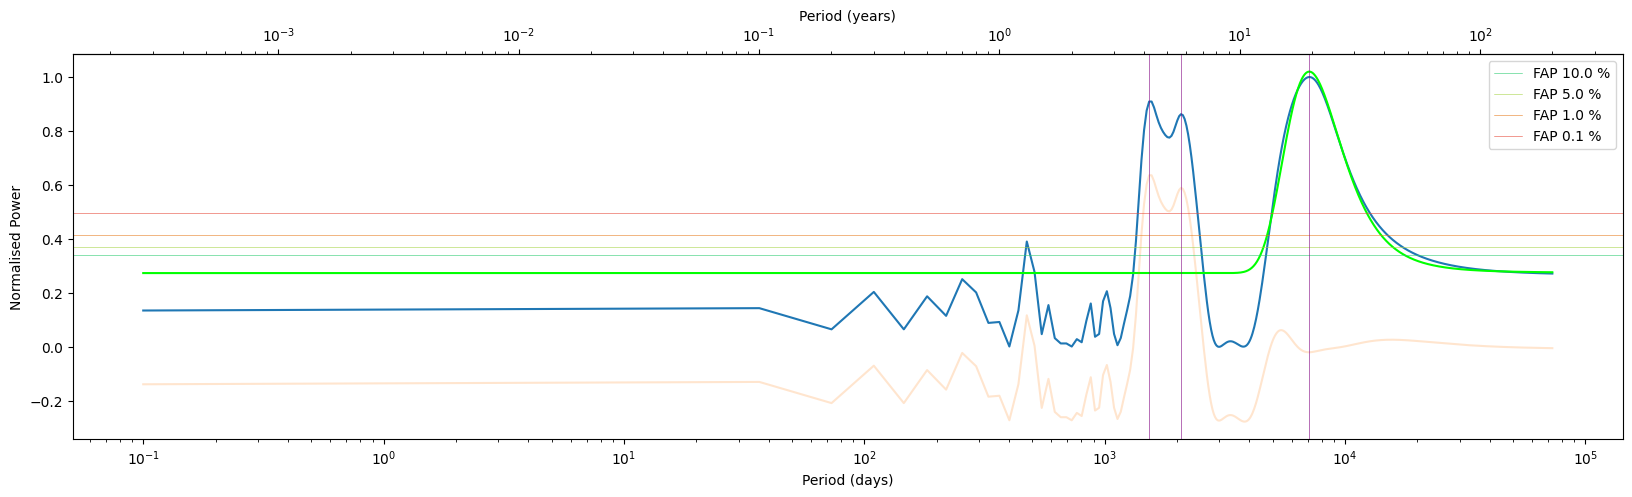

In [56]:
snr, popt, resid_lsp = find_snr(powers, freqs, dom_idx, dom_peak_idx, peak_periods, peak_heights)

print(snr)

# Accumulate — do NOT reset accepted_periods here (MPFIT keeps all accepted periods)
if snr > 4:
    accepted_periods.append(dominant_period)

## Plot
fig, ax = plt.subplots(figsize=(20, 5))
ax.set_xscale('log')
# ax.set_yscale('log')
ax.plot(periods, powers)

if popt is not None:
    ax.plot(periods, gaussian(freqs, *popt), color = 'lime')
    ax.plot(periods, powers-gaussian(freqs, *popt), alpha = 0.2)

# Axis labels
ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365.25, lambda y: y * 365.25))
ax2.set_xlabel('Period (years)')
ax.set_xlabel('Period (days)')
ax.set_ylabel('Normalised Power')

# Plot FAPs
fap_colors = ['#2ecc71', '#a8d44a', '#e67e22', '#e74c3c']
for power_invFAP, fap_color, fap_level in zip(power_invFAPs, fap_colors, FAPs):
    ax.axhline(power_invFAP, color = fap_color, label = f'FAP {fap_level * 100} %', lw = 0.4)

# Plot peaks
for peak_period in peak_periods:
    ax.axvline(peak_period, color = 'purple', lw = 0.4)

plt.legend()
plt.show()


- Ok so the SNR is greater than four.
- Now we perform the simultaneous refit.

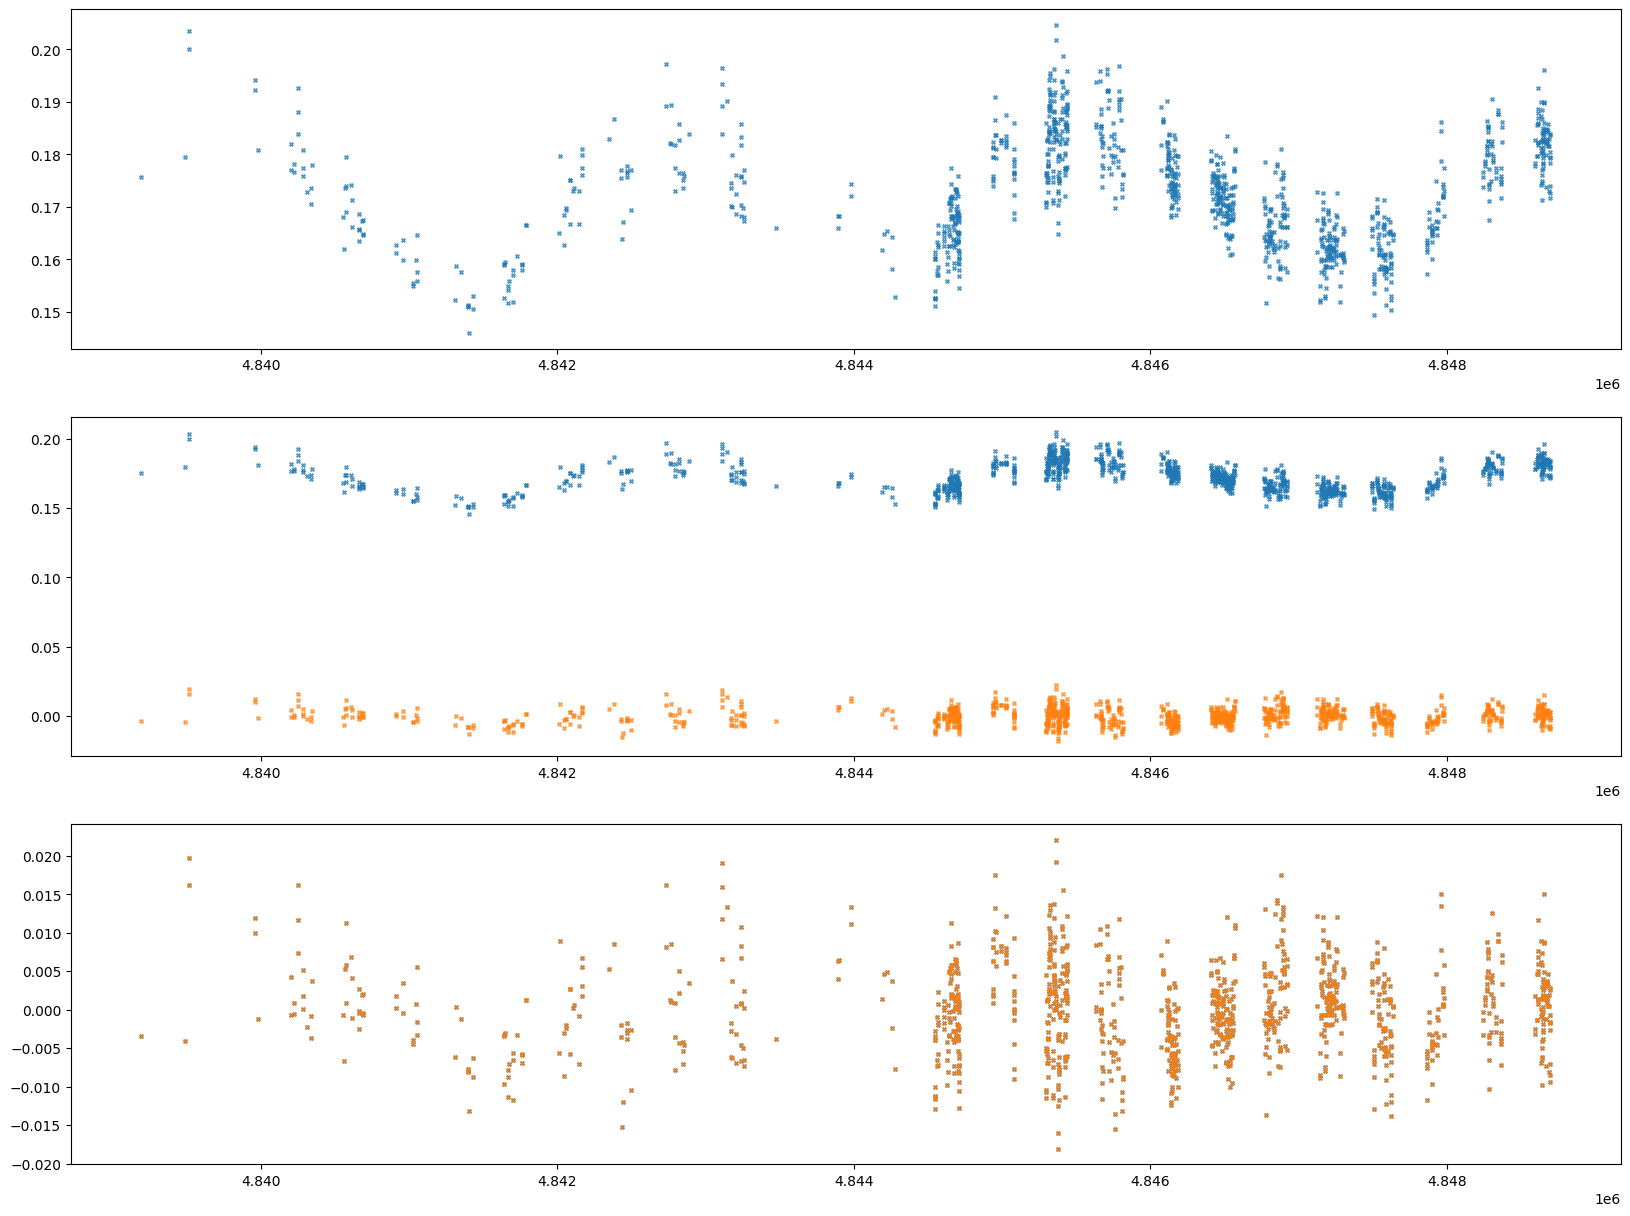

In [66]:
resid2, params = simultaneous_fit(train_df['day'], train_df['sind'], accepted_periods)
fig, ax = plt.subplots(3, figsize=(20,3*5))
ax[0].scatter(train_df['day'], train_df['sind'], marker='x', s=7, alpha=0.75, label = 'original')
ax[1].scatter(train_df['day'], train_df['sind'], marker='x', s=7, alpha=0.75, label = 'original')
ax[1].scatter(train_df['day'], resid1, marker='x', s=7, alpha=0.75, label = "resid1")
ax[2].scatter(train_df['day'], resid1, marker='x', s=7, alpha=0.75, label = "resid1")
ax[2].scatter(train_df['day'], resid2, marker='x', s=7, alpha=0.75, label = "resid2")

plt.show()

---


In [57]:
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

def dominant_peak(t, resid, freqs, ax = None):
    '''
    Finds peak from the residual time series.
    If this is the first round then resid is just the data.
    This is a helper function for find_peaks.
    Returns the dominant peak of a signal (period, amplitude).
    Find_peaks fits simultaneaously all the sinusoids.
    '''
    ls = LombScargle(t, resid)
    powers = ls.power(freqs) # Pulls out the powers at those frequencies

    # Normalisation for interpretability
    max_power = max(powers)
    powers /= max_power  # was: power /= max_power (typo)

    # Calculate FAPs
    FAPs = np.array([10,5,1,0.1])/100
    power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
    power_invFAPs /= max_power # Normalise onto our scale of 0 to 1

    # fap_colors = ['#aaaaaa', '#888888', '#444444', '#111111']
    if ax is not None:
        pass  # TODO: add plotting logic here


0.04474546611967689
[  31.49270927   40.25346535  117.64014401  138.08190819  167.28442844
  192.10657066  254.8919892   270.95337534  295.77551755  324.9780378
  338.84923492  417.6960396   484.86183618  535.96624662 1078.40306031
 1523.01143114 2991.89819982 5007.60216022] {'peak_heights': array([0.0545385 , 0.05206056, 0.05548637, 0.05701666, 0.05309274,
       0.0467561 , 0.0544183 , 0.05071007, 0.10062945, 0.45093232,
       0.18118007, 0.46867476, 0.07663914, 0.0594807 , 0.08314174,
       0.17075122, 1.        , 0.27014847])}
[0.0308118  0.03288123 0.03980509 0.04474547]


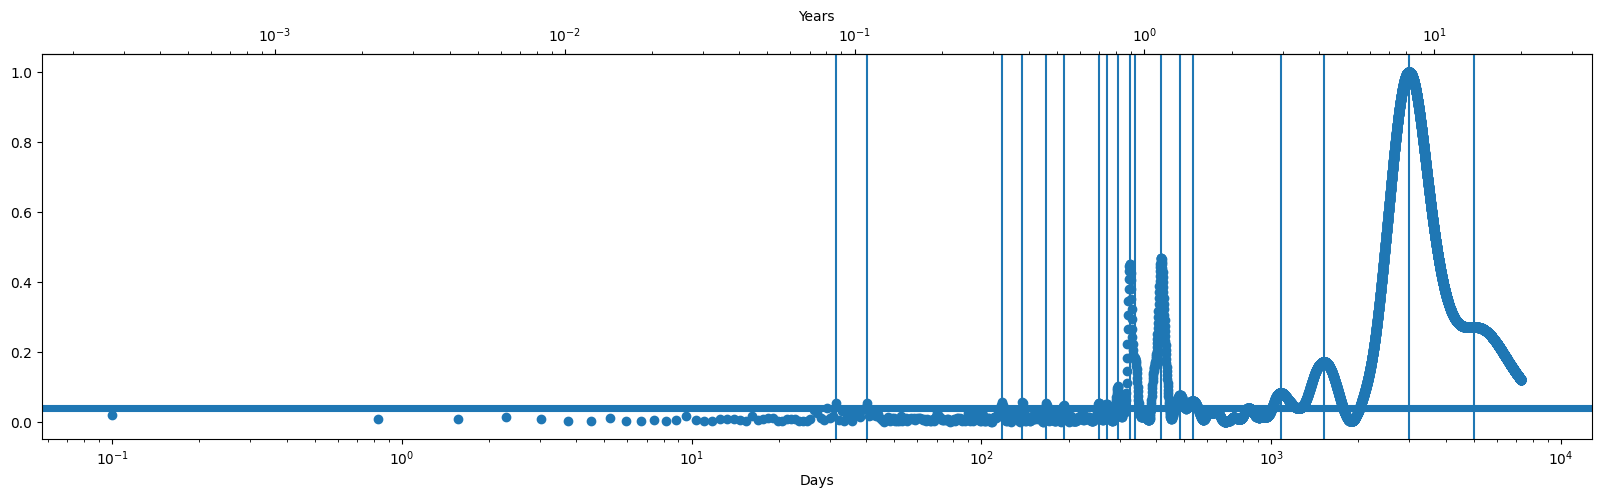

The best period is 2991.898199819982 days


In [58]:


# Define freq range
min_period = 0.1
max_period = 365*20 # now in days
n_periods = 10000
periods = np.linspace(min_period, max_period, n_periods)
freq = 1 / periods

ls = LombScargle(train_df['day'], train_df['sind'])
power = ls.power(freq)

# # Normalise the powers to frac of max to aid in peak finding
max_power = max(power)
power /= max_power

# noise = np.percentile(power, 75)
# print(max_power)

# FAPs of note
FAPs = np.array([10, 5, 1, 0.01]) / 100
power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
power_invFAPs /= max_power

print(max(power_invFAPs))
# Use float() to ensure a Python scalar — passing a numpy array as height causes a size-mismatch error
noise = float(power_invFAPs[-1])

# Find the Lomb-Scargle peak
peaks, properties = find_peaks(power, height = noise) # peaks is an array of the indices of the input arrays with the peaks
peak_periods = periods[peaks]
print(peak_periods, properties)

# Things for calculating the FAP
N = len(train_df)
T = train_df['day'].max() - train_df['day'].min()
M = T * (1/min_period - 1/max_period)
# print(N,M)

# # FAPs of note
# FAPs = np.array([10, 5, 1, 0.01, 0.001]) / 100
# power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') / max_power
# power_invFAPs = invFAP(N = N, M = M, FAP = FAPs)
# power_invFAPs = 2 * power_invFAPs / (N - 1)  # convert HB units to standard
# power_invFAPs /= max_power
print(power_invFAPs)

# plot the thing
fig, ax = plt.subplots(1, figsize=(20, 5))
ax.set_xscale('log')
ax.scatter(periods, power)

for peak_period in peak_periods:
    ax.axvline(peak_period)
for power_invFAP in power_invFAPs:
    ax.axhline(power_invFAP)

ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365, lambda y: y * 365))
ax2.set_xlabel('Years')
ax.set_xlabel('Days')

plt.show()

# print the best period
best_period = periods[np.argmax(power)]
print(f"The best period is {best_period} days")


In [59]:
# Now remove the peak prominence
# peaks, properties['peak_heights']
peaks = list(zip(peak_periods, properties['peak_heights']))
highest_idx = np.argmax(properties['peak_heights'])
dominant_period = peak_periods[highest_idx]


